In [1]:
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

from ohlc_dss_model.data import remove_incomplete_days, intraday_session_tagging, session_tagging, load_parquet
from ohlc_dss_model.utils import convert_to_timezone

In [2]:
df = load_parquet()
df = convert_to_timezone(df)
print(df.head(5))

shape: (5, 6)
┌────────────────────────────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ DateTime                       ┆ Open    ┆ High    ┆ Low     ┆ Close   ┆ Volume │
│ ---                            ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---    │
│ datetime[ns, America/New_York] ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ u64    │
╞════════════════════════════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ 2011-01-02 18:00:00 EST        ┆ 2220.0  ┆ 2223.75 ┆ 2219.25 ┆ 2220.5  ┆ 889    │
│ 2011-01-02 18:30:00 EST        ┆ 2220.0  ┆ 2222.0  ┆ 2219.75 ┆ 2221.5  ┆ 238    │
│ 2011-01-02 19:00:00 EST        ┆ 2221.75 ┆ 2221.75 ┆ 2219.75 ┆ 2220.0  ┆ 117    │
│ 2011-01-02 19:30:00 EST        ┆ 2220.5  ┆ 2223.0  ┆ 2220.5  ┆ 2222.25 ┆ 74     │
│ 2011-01-02 20:00:00 EST        ┆ 2222.25 ┆ 2222.75 ┆ 2221.75 ┆ 2222.5  ┆ 121    │
└────────────────────────────────┴─────────┴─────────┴─────────┴─────────┴────────┘


Next, we'll check for and handle any duplicated rows. If the dataset is already clean, this check will naturally return empty.

In [3]:
print(df.filter(df.is_duplicated()))

shape: (0, 6)
┌────────────────────────────────┬──────┬──────┬─────┬───────┬────────┐
│ DateTime                       ┆ Open ┆ High ┆ Low ┆ Close ┆ Volume │
│ ---                            ┆ ---  ┆ ---  ┆ --- ┆ ---   ┆ ---    │
│ datetime[ns, America/New_York] ┆ f64  ┆ f64  ┆ f64 ┆ f64   ┆ u64    │
╞════════════════════════════════╪══════╪══════╪═════╪═══════╪════════╡
└────────────────────────────────┴──────┴──────┴─────┴───────┴────────┘


No duplicates found, so we can proceed to the next step.

We will now apply session tagging to separate different trading days. Essentially, this defines which intraday rows belong to a specific daily candle.

In [4]:
df = session_tagging(df)
print(df.head(5))

shape: (5, 7)
┌────────────────────────────────┬─────────┬─────────┬─────────┬─────────┬────────┬────────────┐
│ DateTime                       ┆ Open    ┆ High    ┆ Low     ┆ Close   ┆ Volume ┆ Session    │
│ ---                            ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---    ┆ ---        │
│ datetime[ns, America/New_York] ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ u64    ┆ date       │
╞════════════════════════════════╪═════════╪═════════╪═════════╪═════════╪════════╪════════════╡
│ 2011-01-02 18:00:00 EST        ┆ 2220.0  ┆ 2223.75 ┆ 2219.25 ┆ 2220.5  ┆ 889    ┆ 2011-01-03 │
│ 2011-01-02 18:30:00 EST        ┆ 2220.0  ┆ 2222.0  ┆ 2219.75 ┆ 2221.5  ┆ 238    ┆ 2011-01-03 │
│ 2011-01-02 19:00:00 EST        ┆ 2221.75 ┆ 2221.75 ┆ 2219.75 ┆ 2220.0  ┆ 117    ┆ 2011-01-03 │
│ 2011-01-02 19:30:00 EST        ┆ 2220.5  ┆ 2223.0  ┆ 2220.5  ┆ 2222.25 ┆ 74     ┆ 2011-01-03 │
│ 2011-01-02 20:00:00 EST        ┆ 2222.25 ┆ 2222.75 ┆ 2221.75 ┆ 2222.5  ┆ 121    ┆ 2011-01-03 │
└───────────────

In [5]:
print(df.tail(5))

shape: (5, 7)
┌────────────────────────────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────────┐
│ DateTime                       ┆ Open     ┆ High     ┆ Low      ┆ Close    ┆ Volume ┆ Session    │
│ ---                            ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---    ┆ ---        │
│ datetime[ns, America/New_York] ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ u64    ┆ date       │
╞════════════════════════════════╪══════════╪══════════╪══════════╪══════════╪════════╪════════════╡
│ 2026-04-16 16:30:00 EDT        ┆ 26458.5  ┆ 26471.5  ┆ 26454.5  ┆ 26464.25 ┆ 3569   ┆ 2026-04-16 │
│ 2026-04-16 18:00:00 EDT        ┆ 26460.0  ┆ 26484.5  ┆ 26445.25 ┆ 26482.25 ┆ 3327   ┆ 2026-04-17 │
│ 2026-04-16 18:30:00 EDT        ┆ 26482.25 ┆ 26487.25 ┆ 26473.0  ┆ 26475.25 ┆ 1342   ┆ 2026-04-17 │
│ 2026-04-16 19:00:00 EDT        ┆ 26473.5  ┆ 26488.0  ┆ 26470.25 ┆ 26477.25 ┆ 1583   ┆ 2026-04-17 │
│ 2026-04-16 19:30:00 EDT        ┆ 26477.0  ┆ 26488.5  ┆ 26472.0  ┆ 26479.5  

Next, we need to map the intraday session intervals to pre-target period and target period.
Note that you can adjust these specific time boundaries in the `config.py` file.

In [6]:
df = intraday_session_tagging(df)
print(df.select(["DateTime", "Intraday_Session"]).head(5))

shape: (5, 2)
┌────────────────────────────────┬──────────────────┐
│ DateTime                       ┆ Intraday_Session │
│ ---                            ┆ ---              │
│ datetime[ns, America/New_York] ┆ str              │
╞════════════════════════════════╪══════════════════╡
│ 2011-01-02 18:00:00 EST        ┆ Pre_Target_1     │
│ 2011-01-02 18:30:00 EST        ┆ Pre_Target_1     │
│ 2011-01-02 19:00:00 EST        ┆ Pre_Target_1     │
│ 2011-01-02 19:30:00 EST        ┆ Pre_Target_1     │
│ 2011-01-02 20:00:00 EST        ┆ Pre_Target_1     │
└────────────────────────────────┴──────────────────┘


In [7]:
df.group_by("Session").agg(
    pl.col("Intraday_Session").n_unique().alias("n_sessions")
).filter(pl.col("n_sessions") != 4)

Session,n_sessions
date,u32
2026-01-19,3
2020-12-18,3
2021-09-06,3
2016-09-16,3
2012-01-03,3
…,…
2018-05-28,3
2025-03-21,3
2012-09-03,3


There seems to be incomplete data here, we can drop this rows, this may vary depending on datasets ideally there should be none, perhaps if you can get your hands on better datasets it might be better


In [8]:
df = remove_incomplete_days(df)
df.group_by("Session").agg(
    pl.col("Intraday_Session").n_unique().alias("n_sessions")
)

Session,n_sessions
date,u32
2012-09-24,4
2024-04-04,4
2014-03-17,4
2017-05-18,4
2022-10-25,4
…,…
2020-07-28,4
2018-10-09,4
2014-02-12,4


Now we will perform a descriptive analysis to understand the volatility profiles across different sessions, allowing us to compare our findings against the Andersen-Bollerslev Intraday Periodicity hypothesis.

First, we'll calculate the log returns of the intraday closes. Log returns are mathematically convenient for financial time series (as discussed in Gregory Andersen's literature). We will use these returns to estimate standard deviation (volatility) and kurtosis (distribution shape) for each session.

Additionally, we will calculate the candle ranges using `ln(High / Low)`. This metric captures the proportional size of each candle, which helps us visualize session volatility later on.

In [9]:
descriptive_stats = df.with_columns(
    (pl.col("Close") / pl.col("Close").shift(1).over("Session")).log().alias("Log_Return_Close"),
    (pl.col("High") / pl.col("Low")).log().alias("Candle_Range"),
)
print(
    descriptive_stats.select(
        ["DateTime", "Session", "Intraday_Session", "Log_Return_Close", "Candle_Range"]
    ).tail(5)
)

shape: (5, 5)
┌────────────────────────────────┬────────────┬──────────────────┬──────────────────┬──────────────┐
│ DateTime                       ┆ Session    ┆ Intraday_Session ┆ Log_Return_Close ┆ Candle_Range │
│ ---                            ┆ ---        ┆ ---              ┆ ---              ┆ ---          │
│ datetime[ns, America/New_York] ┆ date       ┆ str              ┆ f64              ┆ f64          │
╞════════════════════════════════╪════════════╪══════════════════╪══════════════════╪══════════════╡
│ 2026-04-16 14:30:00 EDT        ┆ 2026-04-16 ┆ Target_2         ┆ 0.002443         ┆ 0.003038     │
│ 2026-04-16 15:00:00 EDT        ┆ 2026-04-16 ┆ Target_2         ┆ 0.000274         ┆ 0.001229     │
│ 2026-04-16 15:30:00 EDT        ┆ 2026-04-16 ┆ Target_2         ┆ 0.001493         ┆ 0.00222      │
│ 2026-04-16 16:00:00 EDT        ┆ 2026-04-16 ┆ Target_2         ┆ -0.001011        ┆ 0.001889     │
│ 2026-04-16 16:30:00 EDT        ┆ 2026-04-16 ┆ Target_2         ┆ 0.000236  

In [10]:
statistics = descriptive_stats.group_by("Intraday_Session").agg(
    pl.col("Log_Return_Close").std().alias("Std_Deviation"),
    pl.col("Log_Return_Close").kurtosis().alias("Kurtosis"),
    pl.col("Log_Return_Close").skew().alias("Skewness"),
    pl.col("Candle_Range").mean().alias("Mean_Candle_Range"),
    pl.col("Candle_Range").max().alias("Maximum_Candle_Range")
)
print(statistics)

shape: (4, 6)
┌──────────────────┬───────────────┬───────────┬───────────┬───────────────────┬───────────────────┐
│ Intraday_Session ┆ Std_Deviation ┆ Kurtosis  ┆ Skewness  ┆ Mean_Candle_Range ┆ Maximum_Candle_Ra │
│ ---              ┆ ---           ┆ ---       ┆ ---       ┆ ---               ┆ nge               │
│ str              ┆ f64           ┆ f64       ┆ f64       ┆ f64               ┆ ---               │
│                  ┆               ┆           ┆           ┆                   ┆ f64               │
╞══════════════════╪═══════════════╪═══════════╪═══════════╪═══════════════════╪═══════════════════╡
│ Pre_Target_1     ┆ 0.001082      ┆ 51.740954 ┆ -0.223647 ┆ 0.001312          ┆ 0.045185          │
│ Pre_Target_2     ┆ 0.001453      ┆ 73.811264 ┆ 1.363462  ┆ 0.001856          ┆ 0.07601           │
│ Target_1         ┆ 0.002922      ┆ 11.63827  ┆ -0.399002 ┆ 0.003894          ┆ 0.067456          │
│ Target_2         ┆ 0.00259       ┆ 33.238162 ┆ 0.343611  ┆ 0.002861        

Our descriptive statistics show that both the standard deviation and average candle ranges for the New York session are roughly twice as large as those in Asia or London. This confirms that New York is significantly more volatile on average, aligning perfectly with the Andersen-Bollerslev Intraday Periodicity hypothesis.


Finally, the exceptionally high kurtosis values across all sessions indicate heavily leptokurtic distributions (where a normal, mesokurtic distribution would sit around 3). This highlights the presence of frequent tail events or outliers. Such characteristics strongly justify using non-Gaussian models for our volatility forecasting.

Next, we'll create a violin plot to visualize the distribution of candle ranges across all sessions.

Given that the maximum candle range is significantly larger than the mean, plotting everything would skew our view. Removing the extreme outliers above the 99th percentile will give us a much clearer visualization.

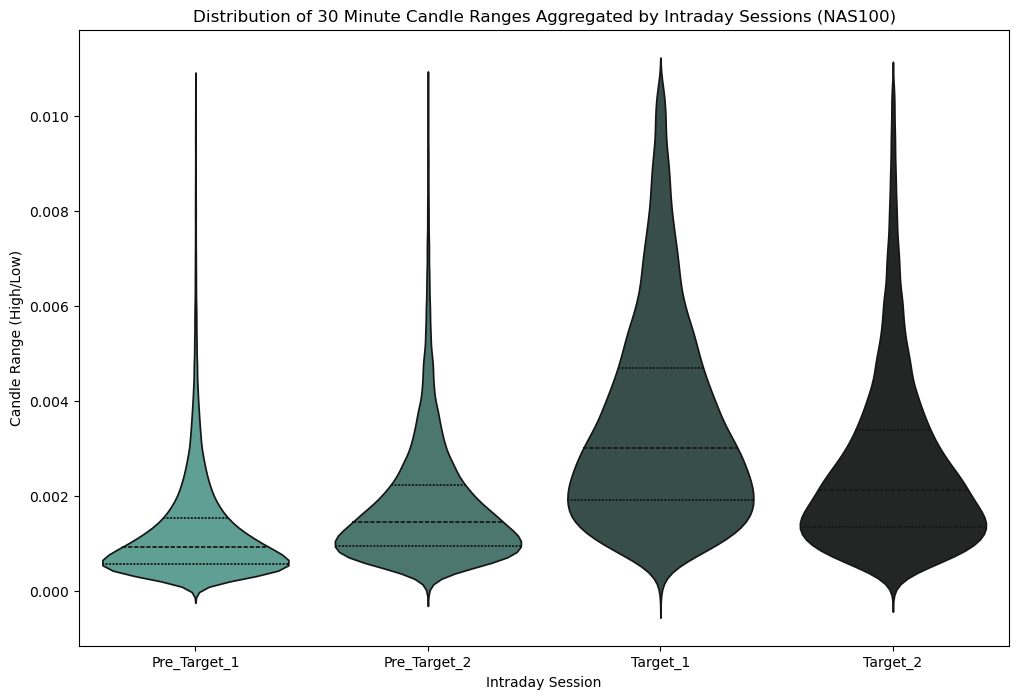

In [11]:
limit = descriptive_stats["Candle_Range"].quantile(0.99)
candle_range_plot = descriptive_stats.filter(pl.col("Candle_Range") < limit)
candle_range_plot = candle_range_plot.to_pandas()

plt.figure(figsize=(12, 8))

sns.violinplot(
    data=candle_range_plot,
    x="Intraday_Session",
    y="Candle_Range",
    order=["Pre_Target_1", "Pre_Target_2", "Target_1", "Target_2"],
    inner="quart",
    density_norm="width",
    palette="dark:#5A9_r",
    hue="Intraday_Session",
)

plt.title(
    "Distribution of 30 Minute Candle Ranges Aggregated by Intraday Sessions (NAS100)"
)
plt.ylabel("Candle Range (High/Low)")
plt.xlabel("Intraday Session")
plt.show()

With a wider distribution body and a higher median, the plot clearly visualizes exactly what our statistics showed: Target_1 session exhibits both a higher central tendency and greater dispersion in its candle ranges followed with Target_2.